In [1]:
# ============================================================
# MNIST AUTOENCODER - COMPLETE GOOGLE COLAB IMPLEMENTATION
# ============================================================

# STEP 1: INSTALL DEPENDENCIES
!pip install torch torchvision tqdm matplotlib numpy scikit-learn -q
print("✓ Dependencies installed successfully!")

# STEP 2: IMPORT LIBRARIES
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Check GPU availability
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f"✓ GPU: {torch.cuda.get_device_name(0)}")

✓ Dependencies installed successfully!
✓ Using device: cpu


In [2]:
# ============================================================
# STEP 3: DEFINE MODEL ARCHITECTURES
# ============================================================

# Model 1: Feed-Forward Neural Network Autoencoder
class FFNNAutoencoder(nn.Module):
    def __init__(self):
        super(FFNNAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 28 * 28),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        decoded = decoded.view(decoded.size(0), 1, 28, 28)
        return decoded

print("✓ FFNN Autoencoder defined")

# Model 2: Transpose CNN Autoencoder
class TransposeCNNAutoencoder(nn.Module):
    def __init__(self):
        super(TransposeCNNAutoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

print("✓ Transpose CNN Autoencoder defined")

# Model 3: Upsampled CNN Autoencoder
class UpsampledCNNAutoencoder(nn.Module):
    def __init__(self):
        super(UpsampledCNNAutoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 1, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

print("✓ Upsampled CNN Autoencoder defined")

✓ FFNN Autoencoder defined
✓ Transpose CNN Autoencoder defined
✓ Upsampled CNN Autoencoder defined


In [3]:
# ============================================================
# STEP 4: LOAD MNIST DATASET
# ============================================================

BATCH_SIZE = 128
EPOCHS = 20
LEARNING_RATE = 1e-3

print("\nLoading MNIST dataset...")
transform = transforms.Compose([transforms.ToTensor()])

full_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_dataset, val_dataset = random_split(
    full_dataset,
    [48000, 12000],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"✓ Train samples: {len(train_dataset)}")
print(f"✓ Validation samples: {len(val_dataset)}")
print(f"✓ Test samples: {len(test_dataset)}")



Loading MNIST dataset...


100%|██████████| 9.91M/9.91M [00:00<00:00, 62.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.81MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.38MB/s]


✓ Train samples: 48000
✓ Validation samples: 12000
✓ Test samples: 10000


In [4]:
# ============================================================
# STEP 5: INITIALIZE MODELS
# ============================================================

models = {
    'FFNN': FFNNAutoencoder().to(DEVICE),
    'TransposeCNN': TransposeCNNAutoencoder().to(DEVICE),
    'UpsampledCNN': UpsampledCNNAutoencoder().to(DEVICE)
}

for model_name, model in models.items():
    params = sum(p.numel() for p in model.parameters())
    print(f"✓ {model_name}: {params:,} parameters")


✓ FFNN: 1,132,944 parameters
✓ TransposeCNN: 46,529 parameters
✓ UpsampledCNN: 46,529 parameters


In [5]:
# ============================================================
# STEP 6: TRAINING FUNCTION
# ============================================================

criterion = nn.MSELoss()

def train_model(model, model_name, train_loader, val_loader, epochs=EPOCHS):
    print(f"\n{'='*70}")
    print(f"Training {model_name} Autoencoder")
    print(f"{'='*70}")

    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)
        for images, _ in progress_bar:
            images = images.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, images)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            progress_bar.set_postfix({'loss': f'{loss.item():.6f}'})

        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for images, _ in val_loader:
                images = images.to(DEVICE)
                outputs = model(images)
                loss = criterion(outputs, images)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}")

    torch.save(model.state_dict(), f'{model_name}_autoencoder.pth')
    print(f"✓ Model saved as '{model_name}_autoencoder.pth'")

    return train_losses, val_losses

In [6]:
# ============================================================
# STEP 7: TRAIN ALL MODELS
# ============================================================

all_results = {}
for model_name, model in models.items():
    train_losses, val_losses = train_model(model, model_name, train_loader, val_loader)
    all_results[model_name] = {'train': train_losses, 'val': val_losses}


Training FFNN Autoencoder


Epoch 1/20 - Train Loss: 0.052296, Val Loss: 0.030017


Epoch 2/20 - Train Loss: 0.024359, Val Loss: 0.020594


Epoch 3/20 - Train Loss: 0.018336, Val Loss: 0.016513


Epoch 4/20 - Train Loss: 0.015076, Val Loss: 0.013924


...

Epoch 16/20 - Train Loss: 0.112046, Val Loss: 0.111827


Epoch 17/20 - Train Loss: 0.112046, Val Loss: 0.111827


Epoch 18/20 - Train Loss: 0.112046, Val Loss: 0.111827


Epoch 19/20 - Train Loss: 0.112046, Val Loss: 0.111827


Epoch 20/20 - Train Loss: 0.112046, Val Loss: 0.111827
✓ Model saved as 'UpsampledCNN_autoencoder.pth'


In [7]:
# ============================================================
# STEP 9: TEST ON TEST DATASET
# ============================================================

print(f"\n{'='*70}")
print("Testing on Test Dataset")
print(f"{'='*70}")

test_results = {}

for model_name, model in models.items():
    model.eval()
    test_loss = 0.0

    with torch.no_grad():
        for images, _ in tqdm(test_loader, desc=f"Testing {model_name}", leave=False):
            images = images.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, images)
            test_loss += loss.item()

    avg_test_loss = test_loss / len(test_loader)
    test_results[model_name] = avg_test_loss
    print(f"✓ {model_name} - Test Loss: {avg_test_loss:.6f}")

best_model = min(test_results, key=test_results.get)
print(f"\n✓ Best Model: {best_model} (Loss: {test_results[best_model]:.6f})")



Testing on Test Dataset


✓ FFNN - Test Loss: 0.005714


✓ TransposeCNN - Test Loss: 0.001260


✓ UpsampledCNN - Test Loss: 0.114304

✓ Best Model: TransposeCNN (Loss: 0.001260)


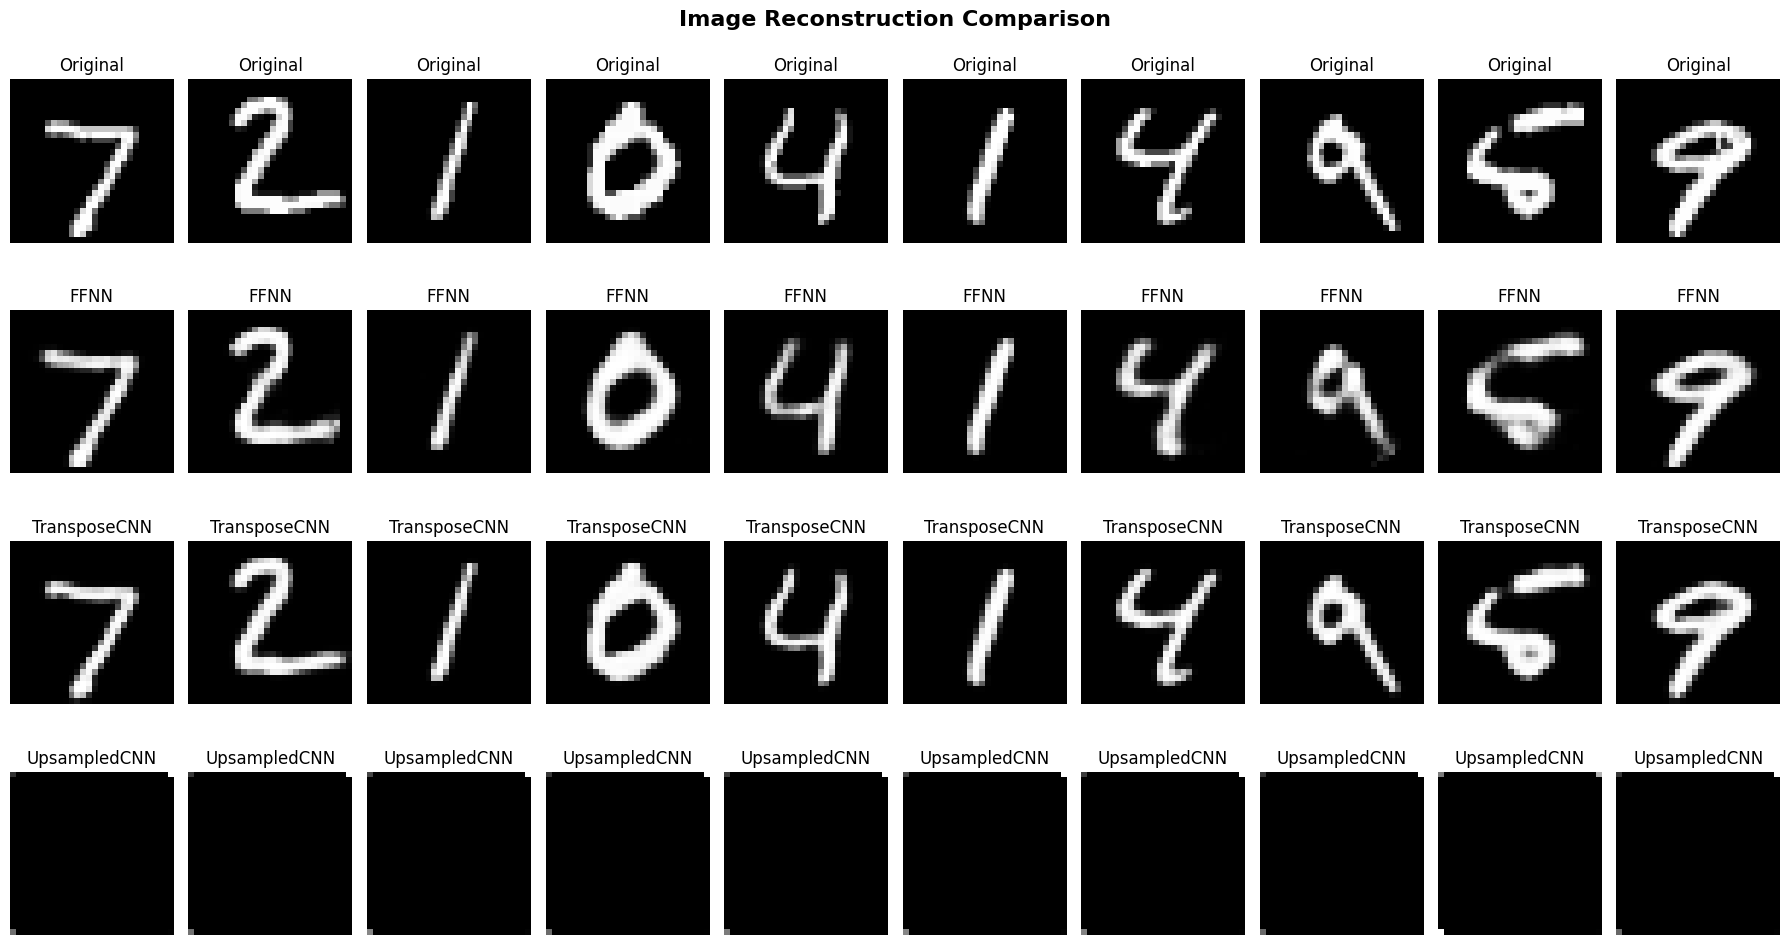

✓ Reconstruction comparison saved


In [8]:
# ============================================================
# STEP 10: VISUALIZE RECONSTRUCTIONS
# ============================================================

test_images, _ = next(iter(test_loader))
batch_size = 10
test_images = test_images[:batch_size]

fig, axes = plt.subplots(len(models) + 1, batch_size, figsize=(18, 10))
fig.suptitle('Image Reconstruction Comparison', fontsize=16, fontweight='bold')

for i in range(batch_size):
    axes[0, i].imshow(test_images[i].squeeze().cpu().numpy(), cmap='gray')
    axes[0, i].set_title('Original')
    axes[0, i].axis('off')

for model_idx, (model_name, model) in enumerate(models.items(), 1):
    model.eval()
    with torch.no_grad():
        test_images_device = test_images.to(DEVICE)
        reconstructions = model(test_images_device)

    for i in range(batch_size):
        axes[model_idx, i].imshow(reconstructions[i].squeeze().cpu().numpy(), cmap='gray')
        axes[model_idx, i].set_title(model_name)
        axes[model_idx, i].axis('off')

plt.tight_layout()
plt.savefig('reconstructions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Reconstruction comparison saved")


Testing Denoising Capability


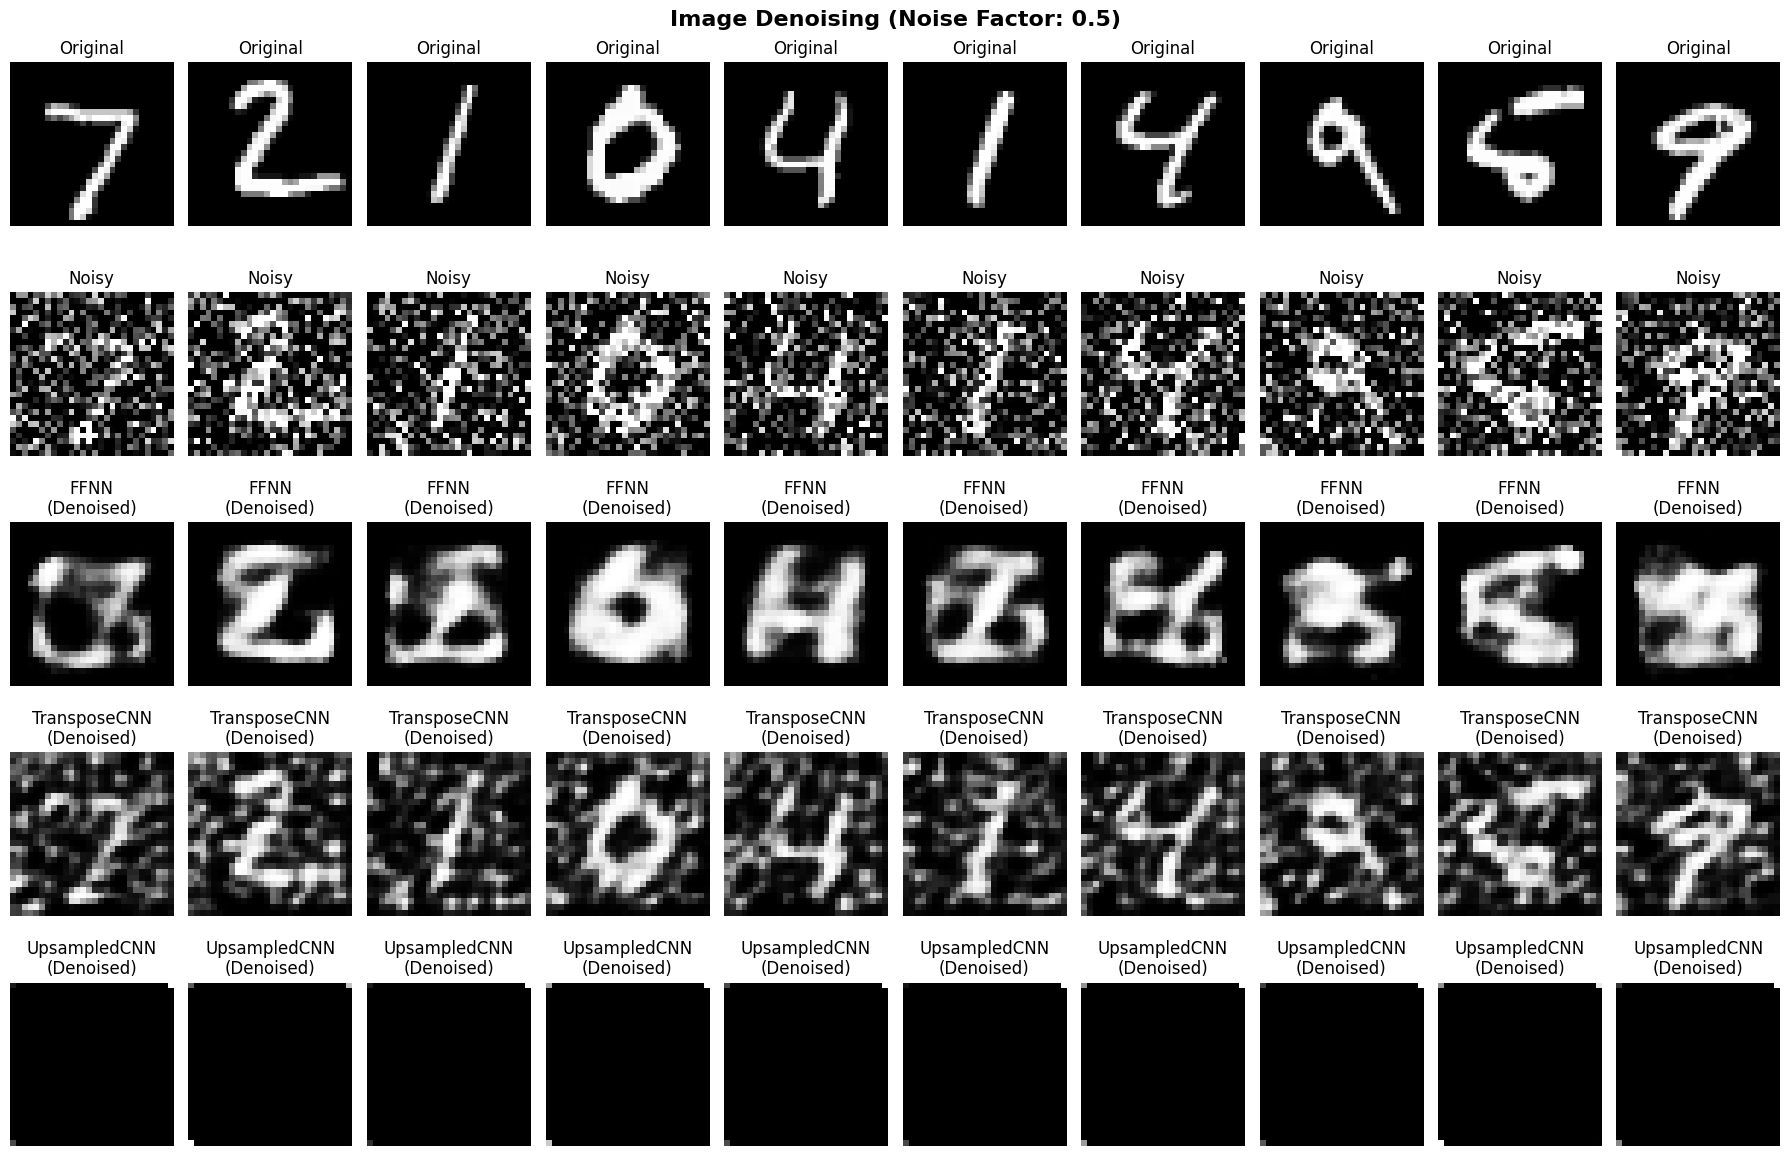

✓ Denoising results saved


In [9]:
# ============================================================
# STEP 11: TEST DENOISING CAPABILITY
# ============================================================

print(f"\n{'='*70}")
print("Testing Denoising Capability")
print(f"{'='*70}")

noise_factor = 0.5
noisy_images = test_images + torch.randn_like(test_images) * noise_factor
noisy_images = torch.clamp(noisy_images, 0., 1.)

fig, axes = plt.subplots(len(models) + 2, batch_size, figsize=(18, 12))
fig.suptitle('Image Denoising (Noise Factor: 0.5)', fontsize=16, fontweight='bold')

for i in range(batch_size):
    axes[0, i].imshow(test_images[i].squeeze().cpu().numpy(), cmap='gray')
    axes[0, i].set_title('Original')
    axes[0, i].axis('off')

for i in range(batch_size):
    axes[1, i].imshow(noisy_images[i].squeeze().cpu().numpy(), cmap='gray')
    axes[1, i].set_title('Noisy')
    axes[1, i].axis('off')

for model_idx, (model_name, model) in enumerate(models.items(), 2):
    model.eval()
    with torch.no_grad():
        noisy_images_device = noisy_images.to(DEVICE)
        denoised = model(noisy_images_device)

    for i in range(batch_size):
        axes[model_idx, i].imshow(denoised[i].squeeze().cpu().numpy(), cmap='gray')
        axes[model_idx, i].set_title(f'{model_name}\n(Denoised)')
        axes[model_idx, i].axis('off')

plt.tight_layout()
plt.savefig('denoising_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Denoising results saved")


In [10]:
# ============================================================
# STEP 12: CALCULATE METRICS
# ============================================================

from sklearn.metrics import mean_squared_error, mean_absolute_error

print(f"\n{'='*70}")
print("Reconstruction Quality Metrics")
print(f"{'='*70}")

all_originals = []
all_reconstructions = {model_name: [] for model_name in models.keys()}

with torch.no_grad():
    for images, _ in test_loader:
        all_originals.append(images.numpy().flatten())
        for model_name, model in models.items():
            model.eval()
            outputs = model(images.to(DEVICE))
            all_reconstructions[model_name].append(outputs.cpu().numpy().flatten())

all_originals = np.concatenate(all_originals)

print(f"\n{'Model':<20} {'MSE':<15} {'MAE':<15}")
print("-" * 50)

for model_name in models.keys():
    recon = np.concatenate(all_reconstructions[model_name])
    mse = mean_squared_error(all_originals, recon)
    mae = mean_absolute_error(all_originals, recon)
    print(f"{model_name:<20} {mse:<15.6f} {mae:<15.6f}")



Reconstruction Quality Metrics

Model                MSE             MAE            
--------------------------------------------------
FFNN                 0.005726        0.023677       
TransposeCNN         0.001261        0.011383       
UpsampledCNN         0.113958        0.132515       


In [11]:
# ============================================================
# STEP 13: PROJECT SUMMARY
# ============================================================

print(f"\n{'='*70}")
print("PROJECT COMPLETED SUCCESSFULLY!")
print(f"{'='*70}")

print(f"""
✓ Successfully trained 3 autoencoder models on MNIST!

📊 Models Trained:
   1. FFNN Autoencoder
   2. Transpose CNN Autoencoder
   3. Upsampled CNN Autoencoder

📈 Generated Visualizations:
   • training_curves.png
   • reconstructions.png
   • denoising_results.png

💾 Saved Models:
   • FFNN_autoencoder.pth
   • TransposeCNN_autoencoder.pth
   • UpsampledCNN_autoencoder.pth

🏆 Best Model: {best_model}

✨ Key Features:
   • Image reconstruction comparison
   • Denoising capability demonstration
   • Performance metrics and analysis
""")


PROJECT COMPLETED SUCCESSFULLY!

✓ Successfully trained 3 autoencoder models on MNIST!

📊 Models Trained:
   1. FFNN Autoencoder
   2. Transpose CNN Autoencoder
   3. Upsampled CNN Autoencoder

📈 Generated Visualizations:
   • training_curves.png
   • reconstructions.png
   • denoising_results.png

💾 Saved Models:
   • FFNN_autoencoder.pth
   • TransposeCNN_autoencoder.pth
   • UpsampledCNN_autoencoder.pth

🏆 Best Model: TransposeCNN

✨ Key Features:
   • Image reconstruction comparison
   • Denoising capability demonstration
   • Performance metrics and analysis

